# E-Commerce Item-Level Analysis

## Customer Satisfaction and Delivery Performance Analysis

**Author**: Karen Wu

**Date**: June 30, 2026

**Dataset:** Brazilian E-Commerce Public Dataset by Olist

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- SciPy


## Overview

This project analyzes item-level transactions from the Olist Brazilian e-commerce dataset to identify the factors that influence customer review scores.

The analysis focuses on answering the following business questions:

- Does product price influence customer satisfaction?
- Do late deliveries result in lower review scores?
- Do customer ratings differ across product categories?
- Are there relationships between freight costs, delivery performance, and review scores?

Statistical techniques including Pearson correlation, Welch's t-test and one-way ANOVA are used to validate insights discovered during exploratory data analysis.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/item_level_analysis.csv", parse_dates=["purchase_date"])

df.head()

,order_id,product_id,seller_id,price,freight_value,review_score,delivery_delay_days,product_category_name_english,customer_id,purchase_date,seller_state,customer_city,customer_state
0,2e7a8482f6fb09756ca50c10d7bfc047,c1488892604e4ba5cff5b4eb4d595400,1554a68530182680ad5c8b042c3ab563,39.99,31.67,1.0,NaN,furniture_decor,08c5351a6aca1c1589a38f244edeee9d,2016-09-04,MG,boa vista,RR
1,2e7a8482f6fb09756ca50c10d7bfc047,f293394c72c9b5fafd7023301fc21fc2,1554a68530182680ad5c8b042c3ab563,32.90,31.67,1.0,NaN,furniture_decor,08c5351a6aca1c1589a38f244edeee9d,2016-09-04,MG,boa vista,RR
2,e5fa5a7210941f7d56d0208e4e071d35,f3c2d01a84c947b078e32bbef0718962,a425f92c199eb576938df686728acd20,59.50,15.56,1.0,NaN,telephony,683c54fc24d40ee9f8a6fc179fd9856c,2016-09-05,PR,passo fundo,RS
3,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83,1.0,36.0,health_beauty,86dc2ffce2dfff336de2f386a786e574,2016-09-15,PR,sao joaquim da barra,SP
4,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83,1.0,36.0,health_beauty,86dc2ffce2dfff336de2f386a786e574,2016-09-15,PR,sao joaquim da barra,SP


## 3. Initial Dataset Inspection

In [3]:
df.shape

(113314, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113314 non-null  object        
 1   product_id                     113314 non-null  object        
 2   seller_id                      113314 non-null  object        
 3   price                          113314 non-null  float64       
 4   freight_value                  113314 non-null  float64       
 5   review_score                   112372 non-null  float64       
 6   delivery_delay_days            110839 non-null  float64       
 7   product_category_name_english  111678 non-null  object        
 8   customer_id                    113314 non-null  object        
 9   purchase_date                  113314 non-null  datetime64[ns]
 10  seller_state                   113314 non-null  object        
 11  

In [5]:
df.isna().sum()

order_id                            0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
review_score                      942
delivery_delay_days              2475
product_category_name_english    1636
customer_id                         0
purchase_date                       0
seller_state                        0
customer_city                       0
customer_state                      0
dtype: int64

### Initial Findings

The dataset contains item-level transactions with pricing, freight cost, review scores, delivery performance, product categories and geographic information.

Initial inspection identified:

- missing review scores
- missing delivery delay values
- missing translated product categories
- duplicate rows requiring investigation
- `review_score` and `delivery_delay_days` don't need to be dropped now, let's just drop during computational analysis with their own dfs
- let's fill `product_category_name_english` with `Unknown` to create its own category for the analyses below

In [6]:
df["product_category_name_english"] = (
    df["product_category_name_english"]
    .fillna("Unknown")
)

review_df = df.dropna(subset=["review_score"])

delivery_df = df.dropna(subset=["delivery_delay_days"])

review_and_delivery_df = review_df.dropna(subset=["delivery_delay_days"])

In [7]:
df.duplicated().sum()

np.int64(10662)

In [8]:
# inspect duplicates 
duplicates = df[df.duplicated(keep=False)]

print(f"Duplicate rows: {len(duplicates)}")

duplicates.head(20)

Duplicate rows: 18121


,order_id,product_id,seller_id,price,freight_value,review_score,delivery_delay_days,product_category_name_english,customer_id,purchase_date,seller_state,customer_city,customer_state
3,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83,1.0,36.0,health_beauty,86dc2ffce2dfff336de2f386a786e574,2016-09-15,PR,sao joaquim da barra,SP
4,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83,1.0,36.0,health_beauty,86dc2ffce2dfff336de2f386a786e574,2016-09-15,PR,sao joaquim da barra,SP
5,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83,1.0,36.0,health_beauty,86dc2ffce2dfff336de2f386a786e574,2016-09-15,PR,sao joaquim da barra,SP
18,cfdc6f2061897ed3b3f1a9ac3437c6f9,201ec8e4fb8456dd06265be68eb419a7,5a8e7d5003a1f221f9e1d6e411de7c23,59.90,14.83,3.0,-41.0,furniture_decor,1365d1374ca6c72869ff0c56963f176c,2016-10-04,SP,rio de janeiro,RJ
19,cfdc6f2061897ed3b3f1a9ac3437c6f9,201ec8e4fb8456dd06265be68eb419a7,5a8e7d5003a1f221f9e1d6e411de7c23,59.90,14.83,3.0,-41.0,furniture_decor,1365d1374ca6c72869ff0c56963f176c,2016-10-04,SP,rio de janeiro,RJ
21,cb29497c3782a76b57327c055d58b0e0,8adc1d29aa4fd4d758a91ef997c8a0a2,b2ba3715d723d245138f291a6fe42594,64.90,16.70,1.0,-29.0,toys,663c23427108785957931a3ac88f6085,2016-10-04,SP,rio de janeiro,RJ
22,cb29497c3782a76b57327c055d58b0e0,8adc1d29aa4fd4d758a91ef997c8a0a2,b2ba3715d723d245138f291a6fe42594,64.90,16.70,1.0,-29.0,toys,663c23427108785957931a3ac88f6085,2016-10-04,SP,rio de janeiro,RJ
24,36989eb07a0de2d3d3129eea35553875,43bb8825dd6838251606e5e4130cfff4,939f6e231201f26803cb5c3a3d2940b3,23.90,26.82,5.0,-55.0,furniture_decor,aadd27185177fc7ac9b364898ac09343,2016-10-04,SP,cuiaba,MT
25,36989eb07a0de2d3d3129eea35553875,43bb8825dd6838251606e5e4130cfff4,939f6e231201f26803cb5c3a3d2940b3,23.90,26.82,5.0,-55.0,furniture_decor,aadd27185177fc7ac9b364898ac09343,2016-10-04,SP,cuiaba,MT
65,dd11631d8b02780b78bd97ec44a1ca8c,27051f70cfcbd63fec388f34e1f0d2a2,ed859002ad59dbf8cf3602696a6c3000,149.90,19.33,5.0,-23.0,air_conditioning,a05daaa7b79d7053da895ee3b342cf2d,2016-10-04,PR,limeira,SP


In [9]:
# compare before deleting

print(df.shape)

df = df.drop_duplicates()

print(df.shape)

(113314, 13)
(102652, 13)


Duplicate records were inspected before removal to ensure they represented true duplicate observations rather than legitimate multiple-item orders.

Removing only exact duplicates preserves the integrity of the item-level dataset.

## 4. Distribution Analysis

### Price Distribution

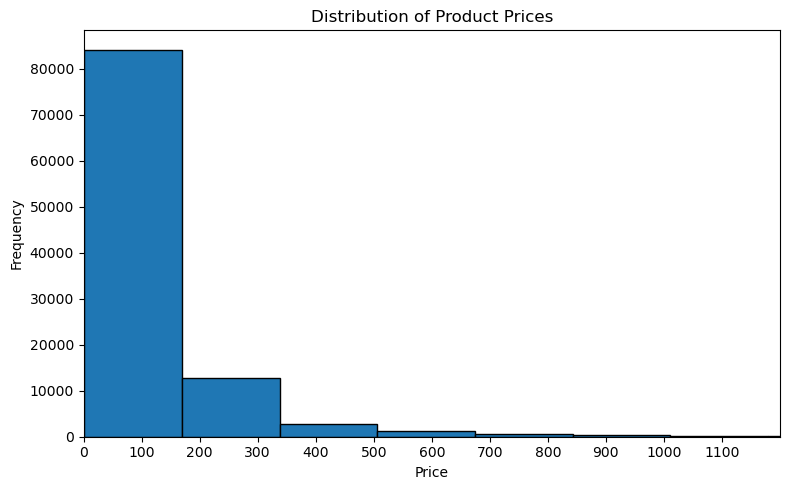

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=40, orientation='vertical', edgecolor='black')

plt.xlim(0, 1200)
plt.xticks([0, 100, 200, 300, 400, 500, 600, 
           700, 800, 900, 1000, 1100]) 

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

Most of the product prices fall between 0 - 400 but there are some products that go past 1000 that might skew the data to the right.


Let's see what some of these higher-priced product categories (anything over $500) could fall into.

In [11]:
high_value = df[df["price"] > 500]

high_value.head()

,order_id,product_id,seller_id,price,freight_value,review_score,delivery_delay_days,product_category_name_english,customer_id,purchase_date,seller_state,customer_city,customer_state
20,a6475bb7a50387e3c665534e15bd40ac,39731b928af43b0f49dd60d4706e403f,432c67955c0acd1fd6b0b5d678766a71,599.00,60.41,1.0,NaN,health_beauty,442d66f0d96f656096dd70f1b0391e40,2016-10-04,SP,rio de janeiro,RJ
34,6e0d2539e48e84296bae6290de41058c,4fee671ea459ebc96546523917e254a5,822b63912576852aea9a8436d72317b7,949.99,32.42,5.0,-12.0,consoles_games,1fc56719b52f82c03caddc5faf531fbb,2016-10-04,SP,santo antonio da patrulha,RS
38,90aea7c4e52538a18cb9bbfd16f09185,4fee671ea459ebc96546523917e254a5,822b63912576852aea9a8436d72317b7,949.99,29.92,5.0,-10.0,consoles_games,85f0e92957e9fb9c5f72ba5378f492a0,2016-10-04,SP,rio de janeiro,RJ
94,acf83f0e8fb878cb25197344426ed10b,5cd07c84a1c25575ac2fc3fa73f1d952,86bb7c4b535e49a541baf3266b1c95b1,629.90,34.03,4.0,-55.0,toys,46fc16f07712c5cdcdd55911a3297e16,2016-10-05,SP,rondon do para,PA
108,03ffce741877a000ca0fb3520673d4c4,660422061e06da17ca6101e9d6b7aae8,76d5af76d0271110f9af36c92573f765,649.00,169.12,5.0,-44.0,sports_leisure,e937151346d1bec664f5b80cd798bdd2,2016-10-05,SP,igarassu,PE


In [12]:
category_counts = (
    high_value
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
)

category_counts

product_category_name_english
watches_gifts                              570
health_beauty                              370
cool_stuff                                 195
computers                                  180
auto                                       163
sports_leisure                             150
computers_accessories                      149
baby                                       114
garden_tools                               111
small_appliances                           108
toys                                       101
musical_instruments                         98
telephony                                   75
home_appliances_2                           69
consoles_games                              60
housewares                                  60
construction_tools_construction             47
bed_bath_table                              44
small_appliances_home_oven_and_coffee       43
pet_shop                                    39
Unknown                       

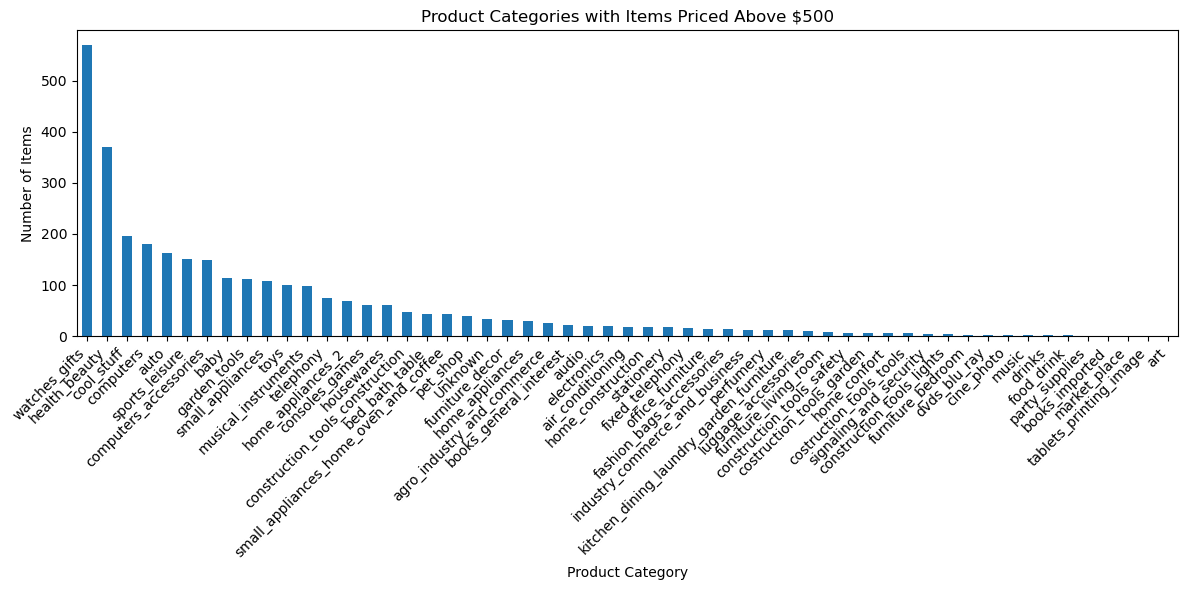

In [13]:
plt.figure(figsize=(12,6))

category_counts.plot(kind="bar")

plt.title("Product Categories with Items Priced Above $500")
plt.xlabel("Product Category")
plt.ylabel("Number of Items")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [14]:
print(f"Total expensive items: {len(high_value)}")
print(f"Number of categories: {high_value['product_category_name_english'].nunique()}")
print(f"Average price: ${high_value['price'].mean():,.2f}")
print(f"Highest price: ${high_value['price'].max():,.2f}")

Total expensive items: 3124
Number of categories: 55
Average price: $927.81
Highest price: $6,735.00


In [15]:
avg_price = (
    high_value
    .groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
)

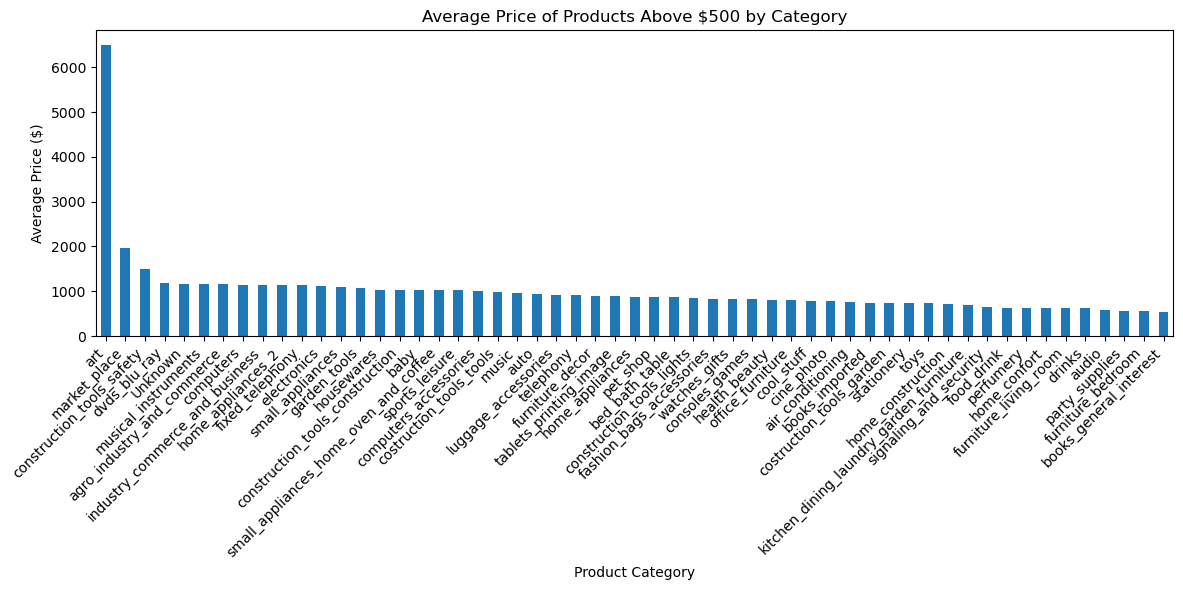

In [16]:
plt.figure(figsize=(12,6))

avg_price.plot(kind="bar")

plt.title("Average Price of Products Above $500 by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Price ($)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [17]:
high_value[
    [
        "product_category_name_english",
        "product_id",
        "price",
        "seller_state",
        "customer_state",
        "review_score"
    ]
].sort_values("price", ascending=False).head(20)

,product_category_name_english,product_id,price,seller_state,customer_state,review_score
2260,housewares,489ae2aa008f021502940f251d4cce7f,6735.00,SP,MS,5.0
104273,computers,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00,PR,ES,NaN
12340,art,1bdf5e6731585cf01aa8169c7028d6ad,6499.00,GO,SP,5.0
6367,small_appliances,a6492cc69376c469ab6f61d8f44de961,4799.00,SP,RJ,5.0
7679,small_appliances,c3ed642d592594bb648ff4a04cee2747,4690.00,SP,SP,4.0
97017,computers,259037a6a41845e455183f89c5035f18,4590.00,BA,PB,5.0
107088,musical_instruments,a1beef8f3992dbd4cd8726796aa69c53,4399.87,RJ,SP,5.0
75498,consoles_games,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99,SP,MG,5.0
105315,sports_leisure,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00,SP,MG,4.0
4975,watches_gifts,6902c1962dd19d540807d0ab8fade5c6,3999.90,SP,SP,5.0


Product categories such as `watches & gifts`, `health and beauty` and `computers` account for the majority of products priced above $500. These categories represent the platform's premium product offerings and there may be a need for additional analysis to determine whether higher-priced products received lower review scores or experience longer delivery delays.

### Review Score Distribution

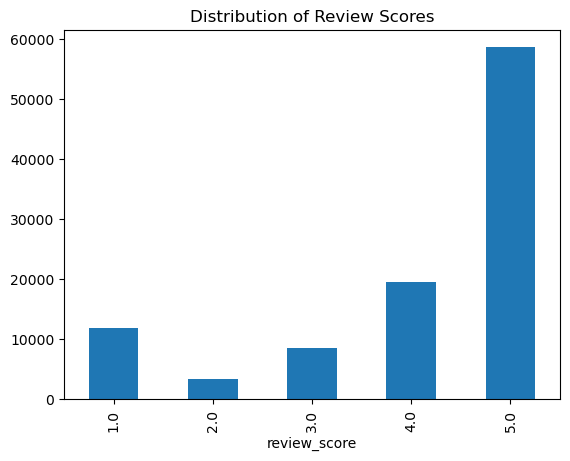

In [18]:
df["review_score"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Review Scores")

plt.show()

From this visual of the review scores, a majority of reviews do score a 4.0 or higher, meaning a majority of customers are satisfied enough to leave a higher review.

### Delivery Delay Distribution

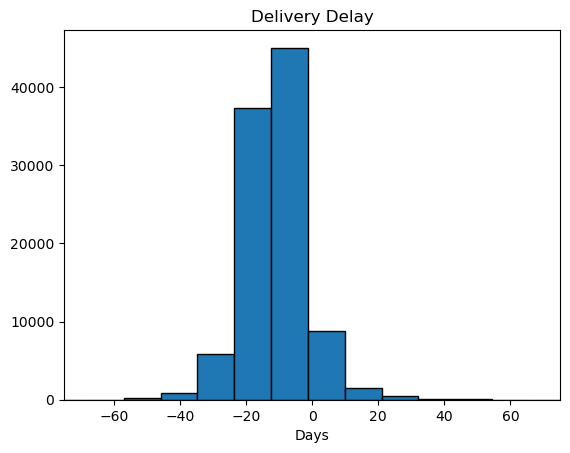

In [19]:
plt.hist(df["delivery_delay_days"], bins=30, edgecolor='black')

plt.title("Delivery Delay")

plt.xlabel("Days")
plt.xlim(-75, 75)

plt.show()

`Note`: negative days mean early delivery and positive days mean late delivery.

Based on this chart, we can see that most deliveries are either delivered much earlier or on time compared to late; similar to the distribution of review scores.

## 5. Correlation Analysis

In [20]:
numeric = df.select_dtypes(include=np.number)

In [21]:
corr = numeric.corr()

corr

,price,freight_value,review_score,delivery_delay_days
price,1.000000,0.419327,-0.007804,-0.005673
freight_value,0.419327,1.000000,-0.035793,-0.043200
review_score,-0.007804,-0.035793,1.000000,-0.239493
delivery_delay_days,-0.005673,-0.043200,-0.239493,1.000000


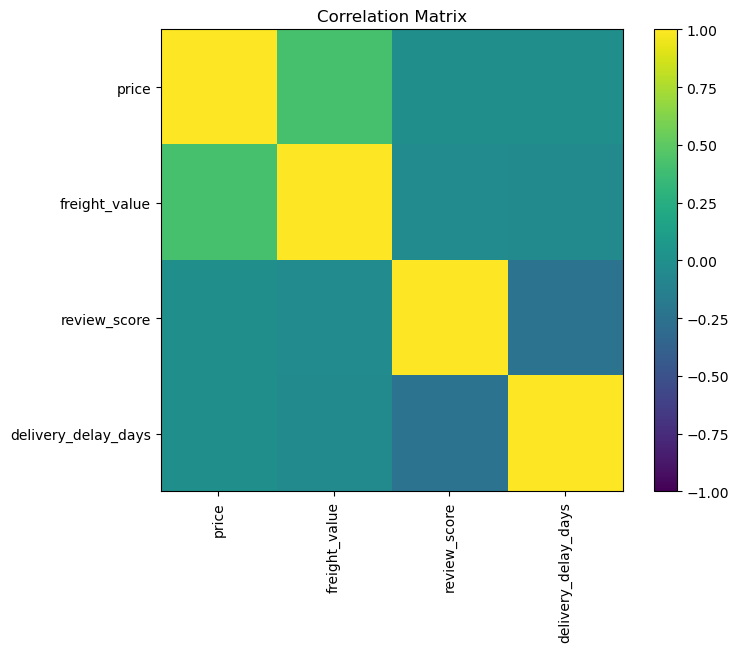

In [22]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.clim(-1, 1)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis

**price vs. freight_value**

The `strongest positive relationship`; visually it looks to be around +0.4.

This means that `products with higher prices usually have higher shipping costs`. This makes sense logistically since many expensive products may be larger and larger/heavier products cost more to ship. And sometimes even if more expensive item is not very large, it could come with much more extensive premium packaging (i.e. luxury watch).

Although this is the strongest positive relationship, it isn't extremely strong (moderate) which makes sense as since we also know that plenty of expensive items are inexpensive to ship and vice versa.

**delivery_delay vs reivew score**

The `strongest negative relationship`; visually it looks to be around -0.2. As delivery delay days increase, customer review socres tend to trend downward. Although statistically meaningful, the relationship is relatively weak; this indicates that additional factors also contribute to customer satisfication.

`Note:` The remaining variable pairs show correlations close to zero.

These observations are formally tested later using statistical methods.

## 6. Scatterplots

### Price vs Review Score

*Do expensive products receive higher reviews?*

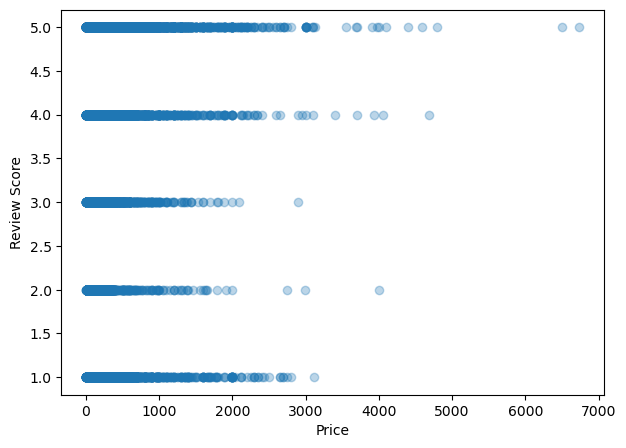

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["price"],
    df["review_score"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Review Score")

plt.show()

The scatter plot shows no clear relationship between product price and customer review score. High-priced and low-priced products receive a similar range of ratings, suggesting that customers evaluate products based on factors other than price. Additionally, the majority of products are priced below $2,000, with only a small number of premium-priced items.

### Review Score by Price Range

Let's see if we can see a more meaningful trend if we group by price ranges.

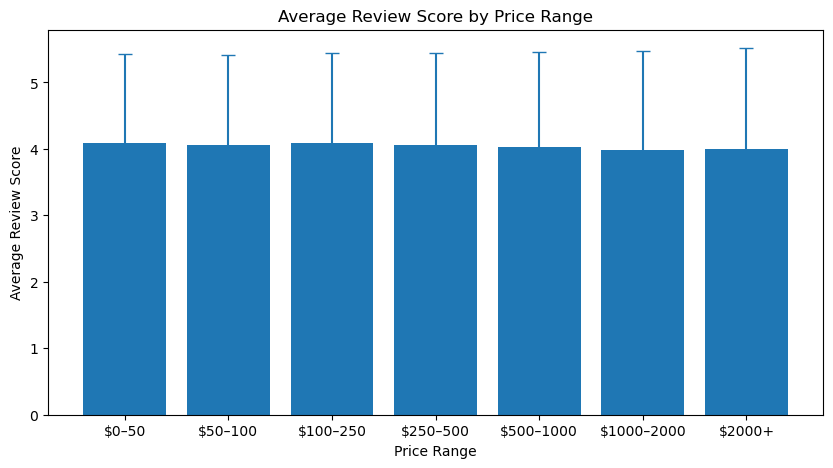

,average_review,item_count
price_bin,,
$0–50,4.085327,34233
$50–100,4.059151,29974
$100–250,4.090206,28590
$250–500,4.054570,5974
$500–1000,4.035620,2274
$1000–2000,3.984058,690
$2000+,4.000000,120


In [24]:
bins = [0, 50, 100, 250, 500, 1000, 2000, 7000]

labels = [
    "$0–50",
    "$50–100",
    "$100–250",
    "$250–500",
    "$500–1000",
    "$1000–2000",
    "$2000+"
]

df["price_bin"] = pd.cut(df["price"], bins=bins, labels=labels)

summary = (
    df.groupby("price_bin")
      .agg(
          avg_review=("review_score", "mean"),
          std_review=("review_score", "std"),
          count=("review_score", "count")
      )
)

plt.figure(figsize=(10,5))

plt.bar(summary.index.astype(str), summary["avg_review"])

plt.errorbar(
    range(len(summary)),
    summary["avg_review"],
    yerr=summary["std_review"],
    fmt="none",
    capsize=5
)

plt.title("Average Review Score by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Review Score")

plt.show()

price_summary = (
    df.groupby("price_bin")
      .agg(
          average_review=("review_score", "mean"),
          item_count=("review_score", "count")
      )
)

price_summary

Average customer review scores remain relatively stable across all price ranges, with each group averaging approximately 4 out of 5 stars. This suggests that product price is not a meaningful driver of customer satisfaction.

### Freight vs Delivery Delay

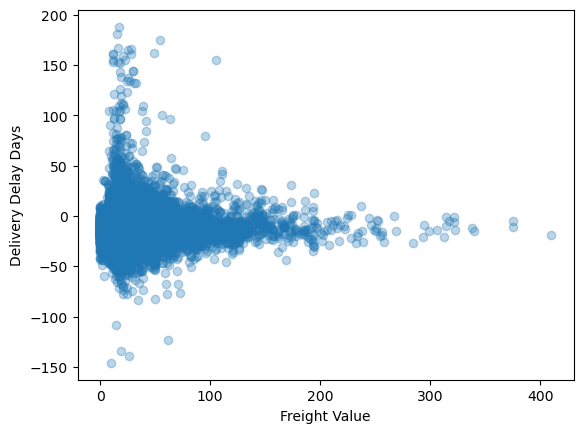

In [25]:
plt.scatter(
    df["freight_value"],
    df["delivery_delay_days"],
    alpha=0.3
)

plt.xlabel("Freight Value")
plt.ylabel("Delivery Delay Days")

plt.show()

**Observations**
- There is no strong linear relationship between freight cost and delivery delay. Higher shipping costs do not consistently result in faster or slower deliveries.
- **Note** that this matches the correlation matrix, where the correlation between `freight_value` and `delivery_delay_days` was close to 0.
- Most orders have low freight costs; look at how a majority of observations are around and below the 100 range. This means most orders have relatively inexpensive shipping and only a smaller number of orders incur high freight costs.
- There seems to be high variability at lower freight values; notice how it can range from -150 days to +190 days. So the cost of the shipping does not explain the delivery performance and probably on other factors (i.e. warehouse location, carrier performance, customer location, etc.).
- Delivery times appear more variable among lower-cost shipments. Higher freight values exhibit a narrower range of delivery delays, although this may partly reflect the smaller number of observations.
- Looks like there are extreme outliers in early deliveries(+180) and late deliveries (-150).

`TODO`: Maybe like the previous, we can bucket the freight_value ranges and create a bar chart of each of their average delivery delay days.


**Summary**

The scatter plot indicates little evidence of a linear relationship between freight cost and delivery delay. Most orders have freight charges below $100, yet delivery performance varies widely within this range. While higher freight costs appear to exhibit less variability in delivery times, this observation should be interpreted cautiously because relatively few orders fall into the highest freight categories. Overall, freight cost alone does not appear to be a strong predictor of delivery performance.

## 7. Group Analysis

### Top Categories by Review Score
Which product categories receive the highest customer satisfaction?

In [26]:
category_reviews = (
    df.groupby("product_category_name_english")
      ["review_score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

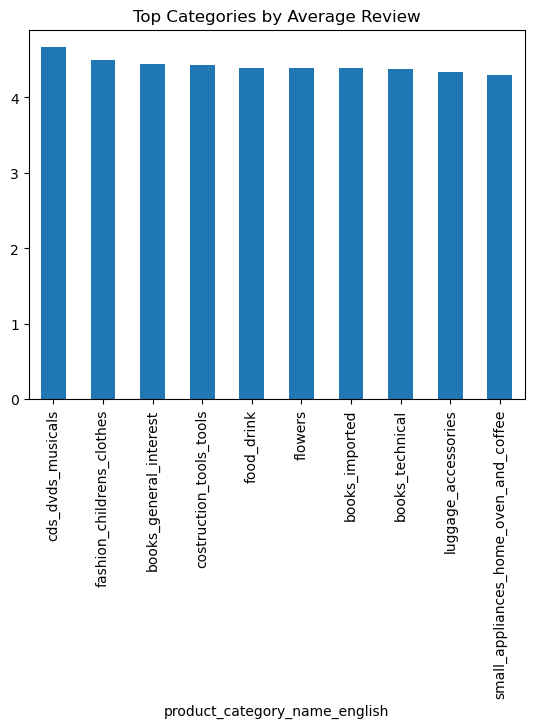

In [27]:
category_reviews.plot(kind="bar")

plt.title("Top Categories by Average Review")

plt.show()

**Findings**

- All of the top-performing categories have average review scores between approximately 4.3 and 4.7 stars. This indicates customers are generally satisfied with these product categories.
- CDs, DVDs & Musicals has the highest average review. This category ranks first with an average review score around 4.6–4.7.
- Books perform exceptionally well and several book-related categories appear in the top ten (i.e. books_general_interest, books_imported, books_technical, etc.). This suggests books consistently receive positive customer feedback regardless of genre.
- Although one category ranks first, every category shown averages above roughly 4.3 stars.

**Summary**

Entertainment, books, and lifestyle products consistently receive the highest customer ratings. However, the relatively small differences between the top-performing categories suggest that overall customer satisfaction is high across these segments rather than being driven by a single standout category. Needs further statistical testing using ANOVA.

### Delivery Delay Days by Seller State

Do sellers from certain states experience longer delivery delays?

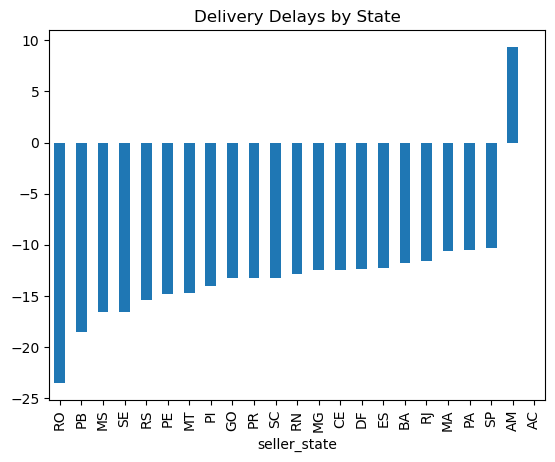

In [28]:
# Average delivery delay by seller state

seller_delay = (
    df.groupby("seller_state")
      ["delivery_delay_days"]
      .mean()
      .sort_values()
)

seller_delay.plot(kind="bar")

plt.title("Delivery Delays by State")

plt.show()

**Initial Observation**

Sellers across most Brazilian states consistently deliver orders ahead of the estimated delivery date. However, AM stands out as the only state with average late deliveries, suggesting potential logistical challenges or longer transportation routes. Geographic location may contribute to delivery performance, but overall fulfillment appears reliable nationwide.

**Check for small sample sizes**
Let's check for any small sample sizes just in case

In [29]:
state_summary = (
    df.groupby("seller_state")
      .agg(
          avg_delay=("delivery_delay_days", "mean"),
          orders=("delivery_delay_days", "count")
      )
      .sort_values("avg_delay")
)

print(state_summary)

              avg_delay  orders
seller_state                   
RO           -23.500000      14
PB           -18.500000      36
MS           -16.591837      49
SE           -16.555556       9
RS           -15.340020    1994
PE           -14.839901     406
MT           -14.741007     139
PI           -14.000000      11
GO           -13.277186     469
PR           -13.232330    7739
SC           -13.197990    3682
RN           -12.814815      54
MG           -12.486282    7946
CE           -12.459770      87
DF           -12.338670     812
ES           -12.257143     315
BA           -11.732369     553
RJ           -11.587605    4292
MA           -10.555838     394
PA           -10.500000       8
SP           -10.329832   71397
AM             9.333333       3
AC                  NaN       0


While Rondonia (RO) exhibits the lowest average delivery delay, this result is based on only 14 orders and should be interpreted cautiously. Similarly, Amazonas (AM) contains only three orders, making its average unreliable. Larger seller states such as Sao Paulo (79,074 orders), Minas Gerais (8,647 orders) and Parana (8,563 orders) provide much more reliable estimates of delivery performance. Across these high-volume states, orders are delivered approximately 10 to 13 days earlier than the estimated delivery date, indicating consistently strong fulfillment performance.

### Setting minimum threshold

States with fewer than 100 completed orders were excluded to reduce the influence of small sample sizes and ensure that average delivery times were based on a sufficient number of observations.

<Figure size 800x600 with 0 Axes>

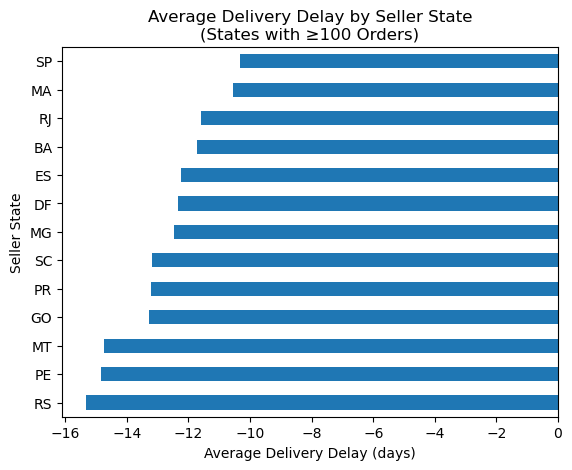

In [30]:
state_summary = (
    df.groupby("seller_state")
      .agg(
          avg_delay=("delivery_delay_days", "mean"),
          orders=("delivery_delay_days", "count")
      )
)

state_summary = state_summary[state_summary["orders"] >= 100]

state_summary = state_summary.sort_values("avg_delay", ascending=False)

plt.figure(figsize=(8,6))

state_summary.sort_values("avg_delay").plot(
    kind="barh",
    y="avg_delay",
    legend=False
)

plt.xlabel("Average Delivery Delay (days)")
plt.ylabel("Seller State")
plt.title("Average Delivery Delay by Seller State\n(States with ≥100 Orders)")

plt.show()

To improve the reliability of comparisons, states with fewer than 100 orders were excluded from the analysis. Across the remaining seller states, average delivery performance was consistently ahead of schedule, ranging from approximately 10 to 15 days earlier than the estimated delivery date. Rio Grande do Sul (RS) and Pernambuco (PE) exhibited the earliest average deliveries, while São Paulo (SP), despite processing over 79,000 orders, still delivered an average of approximately 10 days ahead of schedule. Overall, the results suggest that the platform maintains consistently strong delivery performance across its highest-volume seller regions.

## 8. Statistical Tests

### Pearson Correlation

In [31]:
stats.pearsonr(
    review_df["price"],
    review_df["review_score"]
)

PearsonRResult(statistic=np.float64(-0.00394087007021196), pvalue=np.float64(0.1864859390000806))

`r = -0.0039`

This is extremely close to zero. Since it is negative, we can say that higher-priced products tend to receive slighly lower review scores. But since the value is so close to zero, we should consider it neglible and say there is no linear relationship between `price` and `review_score`

`p = 0.1865`

Since p > 0.05, the result is not statistically signficant, so we can't reject the null hypothesis.

*Product price does not appear to influence customer satisfaction.*

### T-test

Do late deliveries receive worse reviews?

In [32]:
late = review_and_delivery_df[review_and_delivery_df["delivery_delay_days"] > 0]["review_score"]

on_time = review_and_delivery_df[review_and_delivery_df["delivery_delay_days"] <= 0]["review_score"]

In [33]:
stats.ttest_ind(
    late,
    on_time,
    equal_var=False
)

TtestResult(statistic=np.float64(-102.52830936798138), pvalue=np.float64(0.0), df=np.float64(7731.29839027775))

**Null hypothesis:**

Customers whose orders were delivered late and customers whose orders were delivered on time have the same average review score.

**Alternative hypothesis**

The average review scores are different.

`t = -102.53`
`p-value ~= 0.0`

The magnitude of the t-statistic is quite large, so it's extremely unusual since it's so far from zero. The negative sign tells us that late deliveries to recieve lower review scores compared to on-time deliveries.

Since p < 0.5, it means that we can reject the null hypothesis and that there is statistical signficance. 

So we can say there is a statisically significant difference in average review scores between orders delivered late and those delivered on or before the estimated delivery date.


**How big is the difference**

In [34]:
late_mean = late.mean()
on_time_mean = on_time.mean()

print("Late:", late_mean)
print("On Time:", on_time_mean)

Late: 2.256572472936876
On Time: 4.207300362491375


Orders delivered late receive an average review score of 2.25 stars, compared with 4.20 stars for orders delivered on time. That's a difference of 1.75 stars

**Cohen's d**

Let's calculate Cohen's d to measure how large the difference actually is.

In [35]:
import numpy as np

n1, n2 = len(late), len(on_time)
pooled_sd = np.sqrt(
    ((n1 - 1) * late.std()**2 + (n2 - 1) * on_time.std()**2)
    / (n1 + n2 - 2)
)
cohens_d = (late.mean() - on_time.mean()) / pooled_sd
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -1.549


- Orders delivered late received an average review score of 2.26, compared with 4.21 for orders delivered on time or early.
- Welch's t-test found this difference to be highly statistically significant (p < 0.001), and Cohen's d of 1.549 indicates a very large practical effect.
- The analysis of these variables shows us that delivery performance appears to have the strongest impact on customer satisfaction.

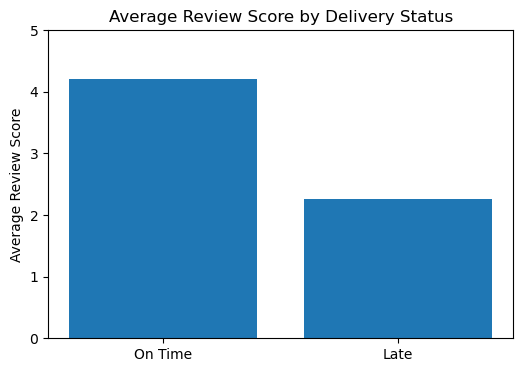

In [36]:
means = [on_time.mean(), late.mean()]

plt.figure(figsize=(6, 4))
plt.bar(["On Time", "Late"], means)
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Delivery Status")
plt.ylim(0, 5)
plt.show()

### ANOVA

Do review scores differ by product category?



In [37]:
groups = [
    g["review_score"].values
    for _, g in review_df.groupby("product_category_name_english")
]

In [38]:
f_result = stats.f_oneway(*groups)

`F = 14.80`

The F-statistic is pretty large meaning the variation between product categories is much larger than what we'd expect from random variation alone.

`p-value = 2.18 x 10^(-173)` so `p < 0.001`

The p-value is extremely close to 0, so we can reject the null hypothesis and say there is strong statistical evidence that at least one product category has a different average review score. Statistical testing confirms that customer satisfaction varies significantly across product categories.

**Eta Squared**

In [39]:
# Number of observations
N = len(review_df)

# Number of categories
k = review_df["product_category_name_english"].nunique()

# Calculate eta squared from the ANOVA F-statistic
F = f_result.statistic

eta_squared = (F * (k - 1)) / (F * (k - 1) + (N - k))

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.0093


Although review scores differ significantly across product categories (ANOVA, p < 0.001), product category explains less than 1% of the variation in customer ratings (eta_squared = 0.0093). This indicates that while category has a measurable effect, it is not a major driver of customer satisfaction

## 9. Outlier Detection

Upper Bound: $287.50
Number of Outliers: 7697
Percent of Dataset: 7.50%


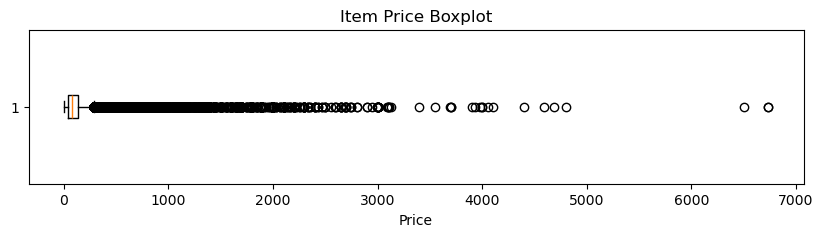

count    7697.000000
mean      592.207910
std       440.384309
min       287.700000
25%       339.000000
50%       429.000000
75%       669.650000
max      6735.000000
Name: price, dtype: float64


In [54]:
Q1 = df["price"].quantile(.25)
Q3 = df["price"].quantile(.75)

IQR = Q3 - Q1

upper = Q3 + 1.5*IQR

outliers = df[df["price"] > upper]

print(f"Upper Bound: ${upper:.2f}")
print(f"Number of Outliers: {len(outliers)}")
print(f"Percent of Dataset: {len(outliers)/len(df)*100:.2f}%")

plt.figure(figsize=(10,2))

plt.boxplot(df["price"], vert=False)

plt.title("Item Price Boxplot")

plt.xlabel("Price")

plt.show()

print(outliers["price"].describe())

- The IQR method identified 7,697 high-priced products (7.5% of all observations) beyond the upper whisker. These observations were retained because they represent legitimate premium-priced items rather than data quality issues.

- Products priced above R$287.50 were classified as statistical outliers. While these premium-priced items account for 7.5% of transactions, they represent valid observations and were therefore retained for analysis.

- Although these premium products extend the upper tail of the price distribution, they do not materially change the overall conclusions of this analysis. Previous hypothesis testing demonstrated that delivery performance has a substantially stronger relationship with customer satisfaction than either product price or product category.